In [ ]:
from google.colab import files
import pandas as pd

print("Please select the file(s) from your local machine to upload:")
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

  if fn.endswith('.csv'):
    try:
      df = pd.read_csv(fn)
      print(f"Successfully loaded '{fn}' into a pandas DataFrame.")
      display(df.head())
    except Exception as e:
      print(f"Error reading CSV file '{fn}': {e}")
  else:
    print(f"File '{fn}' uploaded. You can now process it as needed.")


Please select the file(s) from your local machine to upload:


Saving Crimes_and_Clearances_with_Arson-1985-2024 (1).csv to Crimes_and_Clearances_with_Arson-1985-2024 (1).csv
User uploaded file "Crimes_and_Clearances_with_Arson-1985-2024 (1).csv" with length 6196165 bytes
Successfully loaded 'Crimes_and_Clearances_with_Arson-1985-2024 (1).csv' into a pandas DataFrame.


/tmp/ipykernel_17989/1810528022.py:14: DtypeWarning: Columns (21,22,23,24,25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(fn)


,Year,County,NCICCode,Violent_sum,Homicide_sum,ForRape_sum,Robbery_sum,AggAssault_sum,Property_sum,Burglary_sum,...,MVPLARnao_sum,BILARnao_sum,FBLARnao_sum,COMLARnao_sum,AOLARnao_sum,LT400nao_sum,LT200400nao_sum,LT200nao_sum,LT50200nao_sum,LT50nao_sum
0,1985,San Bernardino County,Adelanto,49,0,2,4,43,164,62,...,11,11,25,1,23,8.0,15.0,NaN,34,33
1,1985,Santa Clara County,Agnews Developmental Center,2,0,0,0,2,38,4,...,3,0,18,0,6,5.0,5.0,NaN,12,10
2,1985,Alameda County,Alameda,405,7,15,220,163,4486,989,...,673,516,183,53,559,540.0,622.0,NaN,916,1159
3,1985,Alameda County,Alameda BART,93,1,3,75,14,1456,6,...,153,108,20,11,212,177.0,150.0,NaN,310,529
4,1985,Alameda County,Alameda Co. Sheriff's Department,427,3,27,166,231,3964,1483,...,109,205,44,11,475,753.0,437.0,NaN,440,498


In [ ]:
selected_counties = [
    'Imperial County',
    'Los Angeles County',
    'Orange County',
    'Fresno County',
    'San Diego County'
]

df_filtered_counties = df[df['County'].isin(selected_counties)].copy()

print(f"Created a new DataFrame with {len(df_filtered_counties)} rows for the selected counties.")display(df_filtered_counties.head())

Created a new DataFrame with 7897 rows for the selected counties.


,Year,County,NCICCode,Violent_sum,Homicide_sum,ForRape_sum,Robbery_sum,AggAssault_sum,Property_sum,Burglary_sum,...,MVPLARnao_sum,BILARnao_sum,FBLARnao_sum,COMLARnao_sum,AOLARnao_sum,LT400nao_sum,LT200400nao_sum,LT200nao_sum,LT50200nao_sum,LT50nao_sum
11,1985,Los Angeles County,Alhambra,469,4,15,199,251,3679,1104,...,183,162,129,5,816,598.0,359.0,NaN,515,607
15,1985,Orange County,Anaheim,1162,16,107,601,438,16409,5160,...,2748,776,1231,108,945,1919.0,1711.0,NaN,2615,3298
20,1985,Los Angeles County,Arcadia,160,2,9,73,76,2193,547,...,211,196,178,5,199,347.0,269.0,NaN,406,325
23,1985,Los Angeles County,Artesia,110,0,2,36,72,474,171,...,25,39,19,1,42,51.0,49.0,NaN,83,54
29,1985,Los Angeles County,Avalon,10,0,1,2,7,173,62,...,2,11,18,2,40,22.0,13.0,NaN,32,21


In [ ]:
numerical_crime_cols = [col for col in df_filtered_counties.select_dtypes(include=['number']).columns if col != 'Year']

df_total_crime_summary = df_filtered_counties.groupby(['Year', 'County'])[numerical_crime_cols].sum().reset_index()

df_total_crime_summary['Total_crime'] = df_total_crime_summary[numerical_crime_cols].sum(axis=1)

df_total_crime_summary = df_total_crime_summary[['Year', 'County', 'Total_crime']]

print(f"Created a new DataFrame 'df_total_crime_summary' with {len(df_total_crime_summary)} rows.")
display(df_total_crime_summary.head())

Created a new DataFrame 'df_total_crime_summary' with 200 rows.


,Year,County,Total_crime
0,1985,Fresno County,2.131845e+05
1,1985,Imperial County,4.400475e+04
2,1985,Los Angeles County,2.597118e+06
3,1985,Orange County,5.841864e+05
4,1985,San Diego County,5.428944e+05


In [ ]:
df_total_crime_summary['Total_crime'] = df_total_crime_summary['Total_crime'] / 10000

print("Updated 'Total_crime' column by dividing by 10,000.")
display(df_total_crime_summary.head())

Updated 'Total_crime' column by dividing by 10,000.


,Year,County,Total_crime
0,1985,Fresno County,21.318446
1,1985,Imperial County,4.400475
2,1985,Los Angeles County,259.711800
3,1985,Orange County,58.418636
4,1985,San Diego County,54.289436


In [ ]:
df_total_crime_summary['Total_crime'] = df_total_crime_summary['Total_crime'] * 10

print("Updated 'Total_crime' column by multiplying by 10.")
display(df_total_crime_summary.head())

Updated 'Total_crime' column by multiplying by 10.


,Year,County,Total_crime
0,1985,Fresno County,213.184459
1,1985,Imperial County,44.004754
2,1985,Los Angeles County,2597.118000
3,1985,Orange County,584.186361
4,1985,San Diego County,542.894361


In [ ]:
df_total_crime_summary = df_total_crime_summary[df_total_crime_summary['Year'] >= 2000]

print(f"Filtered df_total_crime_summary to include years from 2000 onwards. It now has {len(df_total_crime_summary)} rows.")
display(df_total_crime_summary.head())

Filtered df_total_crime_summary to include years from 2000 onwards. It now has 125 rows.


,Year,County,Total_crime
75,2000,Fresno County,208.484656
76,2000,Imperial County,27.721115
77,2000,Los Angeles County,1631.889803
78,2000,Orange County,331.635967
79,2000,San Diego County,412.241049


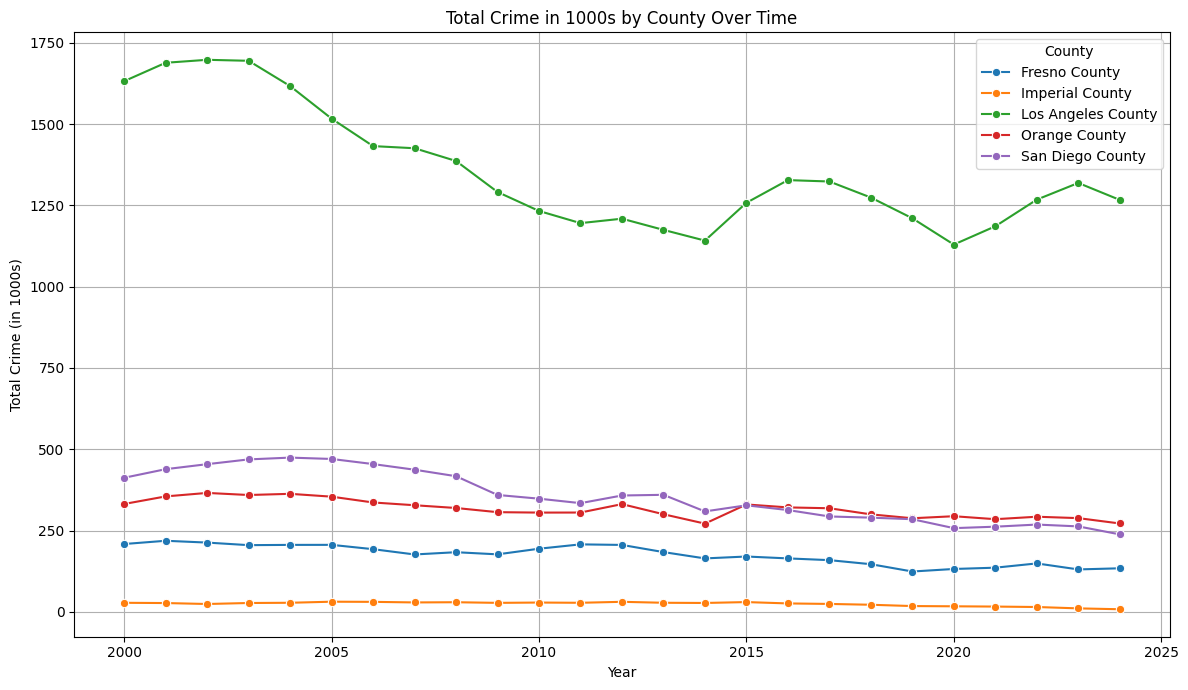

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.lineplot(data=df_total_crime_summary, x='Year', y='Total_crime', hue='County', marker='o')

plt.title('Total Crime in 1000s by County Over Time')
plt.xlabel('Year')
plt.ylabel('Total Crime (in 1000s)')
plt.grid(True)
plt.legend(title='County')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

try:
    df = pd.read_csv('Crimes_and_Clearances_with_Arson-1985-2024 (1).csv', low_memory=False)
except FileNotFoundError:
    print("Error: Original crime data CSV not found. Please ensure 'Crimes_and_Clearances_with_Arson-1985-2024 (1).csv' is available.")
    df_total_crime_summary = pd.DataFrame(columns=['Year', 'County', 'Total_crime'])
else:
    selected_counties = [
        'Imperial County',
        'Los Angeles County',
        'Orange County',
        'Fresno County',
        'San Diego County'
    ]

    df_filtered_counties = df[df['County'].isin(selected_counties)].copy()

    numerical_crime_cols = [col for col in df_filtered_counties.select_dtypes(include=['number']).columns if col != 'Year']
    df_total_crime_summary = df_filtered_counties.groupby(['Year', 'County'])[numerical_crime_cols].sum().reset_index()
    df_total_crime_summary['Total_crime'] = df_total_crime_summary[numerical_crime_cols].sum(axis=1)
    df_total_crime_summary = df_total_crime_summary[['Year', 'County', 'Total_crime']]

    df_total_crime_summary['Total_crime'] = df_total_crime_summary['Total_crime'] / 1000

    df_total_crime_summary = df_total_crime_summary[df_total_crime_summary['Year'] >= 2000]

df_total_crime_summary_2022_2024 = df_total_crime_summary[df_total_crime_summary['Year'] >= 2022].copy()

print(f"Filtered df_total_crime_summary for years 2022-2024. It now has {len(df_total_crime_summary_2022_2024)} rows.")
display(df_total_crime_summary_2022_2024.head())

Filtered df_total_crime_summary for years 2022-2024. It now has 15 rows.


,Year,County,Total_crime
185,2022,Fresno County,146.376
186,2022,Imperial County,14.531
187,2022,Los Angeles County,1246.814
188,2022,Orange County,287.612
189,2022,San Diego County,263.930


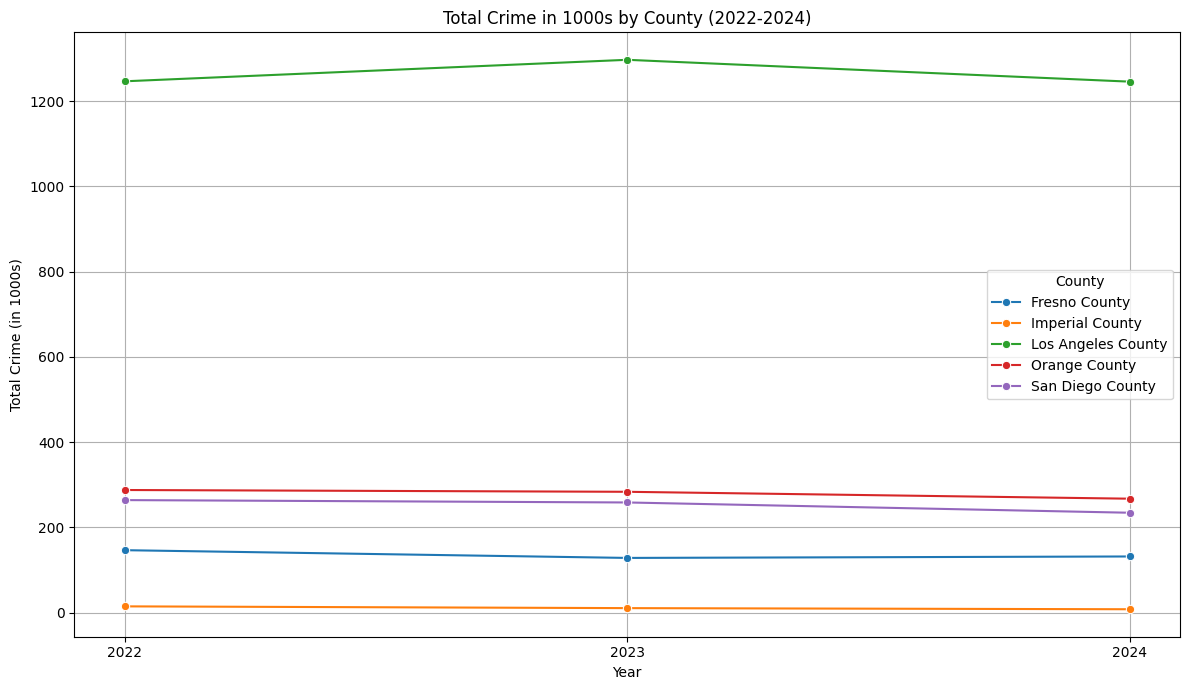

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.lineplot(data=df_total_crime_summary_2022_2024, x='Year', y='Total_crime', hue='County', marker='o')

plt.title('Total Crime in 1000s by County (2022-2024)')
plt.xlabel('Year')
plt.ylabel('Total Crime (in 1000s)')
plt.xticks(ticks=[2022, 2023, 2024])
plt.grid(True)
plt.legend(title='County')
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files
import pandas as pd

print("Please select the file(s) from your local machine to upload:")
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

  if fn.endswith('.csv'):
    try:
      df_new_upload = pd.read_csv(fn)
      print(f"Successfully loaded '{fn}' into a pandas DataFrame named `df_new_upload`.")
      display(df_new_upload.head())
    except Exception as e:
      print(f"Error reading CSV file '{fn}': {e}")
  else:
    print(f"File '{fn}' uploaded. You can now process it as needed.")

Please select the file(s) from your local machine to upload:


Saving National Directory SU 2024_Final.xlsx to National Directory SU 2024_Final.xlsx
User uploaded file "National Directory SU 2024_Final.xlsx" with length 2022444 bytes
File 'National Directory SU 2024_Final.xlsx' uploaded. You can now process it as needed.


In [ ]:
df_excel = pd.read_excel('National Directory SU 2024_Final.xlsx')
print("Successfully loaded 'National Directory SU 2024_Final.xlsx' into a pandas DataFrame named `df_excel`.")
display(df_excel.head())

Successfully loaded 'National Directory SU 2024_Final.xlsx' into a pandas DataFrame named `df_excel`.


/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


,name1,name2,street1,street2,city,state,zip,phone,intake1,intake2,intake1a,intake2a,service_code_info
0,Shelby County Treatment Center,NaN,750 Highway 31 South,NaN,Alabaster,AL,35007,205-216-0200,NaN,NaN,NaN,NaN,SA DT SUMH * OP OD OIT OMB ORT * MU BU NU * PM...
1,Lighthouse of Tallapoosa County Inc,Substance Abuse Rehab Program/Resid,36 Franklin Street,NaN,Alexander City,AL,35010,256-234-4894,NaN,NaN,NaN,NaN,SA HH SUMH * RES RL * BU * RPE PC * ACMA PMAT ...
2,South Central Alabama MHC,Montezuma Complex,205 Academy Drive,NaN,Andalusia,AL,36420,334-428-5050,877-530-0002,NaN,NaN,NaN,SA * RES RS * PC * ACMA * AUPC * MOA * CBT SAC...
3,Anniston Fellowship House Inc,NaN,106 East 22nd Street,NaN,Anniston,AL,36201,256-236-7229,NaN,NaN,NaN,NaN,SA HH * RES RL * RPE PC * ACMA * AURPE * MOA *...
4,Highland Health Systems,New Directions,331 East 8th Street,NaN,Anniston,AL,36207,256-236-8003,256-236-8003 x0,NaN,NaN,NaN,SA SUMH * OP OIT ORT * PC * ACMA * AUPC * MOA ...


In [ ]:
!pip install pgeocode

import pandas as pd
import pgeocode

service_ca = df_excel[df_excel['state'] == 'CA'].copy()

nomi = pgeocode.Nominatim('us')

service_ca['county'] = service_ca['zip'].astype(str).str[:5].str.zfill(5).apply(
    lambda z: nomi.query_postal_code(z)['county_name']
)

target_counties = [
    'Los Angeles',
    'San Diego',
    'Fresno',
    'Orange',
    'Imperial'
]

final_df = service_ca[service_ca['county'].isin(target_counties)]

print("--- Mental Health Facilities by County ---")
print(final_df['county'].value_counts())

Exception ignored in: <function SearchEngine.__del__ at 0x79c39e7baa20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uszipcode/search.py", line 195, in __del__
    if self.ses:
       ^^^^^^^^
AttributeError: 'SearchEngine' object has no attribute 'ses'


--- Mental Health Facilities by County ---
county
Los Angeles    306
Orange         151
San Diego      101
Fresno          23
Imperial         6
Name: count, dtype: int64


In [ ]:
from google.colab import files
import pandas as pd

print("Please select the file(s) from your local machine to upload:")
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

  if fn.endswith('.csv'):
    try:
      df_uploaded = pd.read_csv(fn)
      print(f"Successfully loaded '{fn}' into a pandas DataFrame named `df_uploaded`.")
      display(df_uploaded.head())
    except Exception as e:
      print(f"Error reading CSV file '{fn}': {e}")
  elif fn.endswith(('.xls', '.xlsx')):
    try:
      df_uploaded = pd.read_excel(fn)
      print(f"Successfully loaded '{fn}' into a pandas DataFrame named `df_uploaded`.")
      display(df_uploaded.head())
    except Exception as e:
      print(f"Error reading Excel file '{fn}': {e}")
  else:
    print(f"File '{fn}' uploaded. You can now process it as needed.")

Please select the file(s) from your local machine to upload:


Saving national-directory-su-facilities-2023.xlsx to national-directory-su-facilities-2023.xlsx
User uploaded file "national-directory-su-facilities-2023.xlsx" with length 2115737 bytes
Successfully loaded 'national-directory-su-facilities-2023.xlsx' into a pandas DataFrame named `df_uploaded`.


,Name1,Name2,Street1,Street2,City,State,Zip,Phone,Intake1,Intake2,Intake1a,Intake2a,Service_code_info
0,Shelby County Treatment Center,NaN,750 Highway 31 South,NaN,Alabaster,AL,35007,205-216-0200,NaN,NaN,NaN,NaN,SA DT SUMH * OP OD OIT OMB ORT * MU BU NU * PM...
1,Lighthouse of Tallapoosa County Inc,Substance Abuse Rehab Program/Resid,36 Franklin Street,NaN,Alexander City,AL,35010,256-234-4894,NaN,NaN,NaN,NaN,SA HH SUMH * RES RL * BU * RPE PC * ACMA * AUR...
2,South Central Alabama MHC,Montezuma Complex,205 Academy Drive,NaN,Andalusia,AL,36420,334-428-5050,877-530-0002,NaN,NaN,NaN,SA * OP RES ORT RS * PC * ACMA * AUPC * MOA * ...
3,Anniston Fellowship House Inc,NaN,106 East 22nd Street,NaN,Anniston,AL,36201,256-236-7229,NaN,NaN,NaN,NaN,SA HH * RES RL * RPE PC * ACMA * AURPE * MOA *...
4,State Line Medical LLC,NaN,26928 Main Street,NaN,Ardmore,AL,35739,256-374-6537,NaN,NaN,NaN,NaN,SA DT * OP OD OMB ORT * BU * ACMA * AUPC * DB ...


In [ ]:
!pip install pgeocode

import pandas as pd
import pgeocode

service_ca_2023 = df_uploaded[df_uploaded['State'] == 'CA'].copy()

nomi = pgeocode.Nominatim('us')

service_ca_2023['county'] = service_ca_2023['Zip'].astype(str).str[:5].str.zfill(5).apply(
    lambda z: nomi.query_postal_code(z)['county_name']
)

target_counties = [
    'Los Angeles',
    'San Diego',
    'Fresno',
    'Orange',
    'Imperial'
]

final_df = service_ca_2023[service_ca_2023['county'].isin(target_counties)]

print("--- Mental Health Facilities by County ---")
print(final_df['county'].value_counts())

--- Mental Health Facilities by County ---
county
Los Angeles    328
Orange         181
San Diego      112
Fresno          28
Imperial         6
Name: count, dtype: int64


In [ ]:
from google.colab import files
import pandas as pd

print("Please select the file(s) from your local machine to upload:")
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

  if fn.endswith('.csv'):
    try:
      df_uploaded = pd.read_csv(fn)
      print(f"Successfully loaded '{fn}' into a pandas DataFrame named `df_uploaded`.")
      display(df_uploaded.head())
    except Exception as e:
      print(f"Error reading CSV file '{fn}': {e}")
  elif fn.endswith(('.xls', '.xlsx')):
    try:
      df_uploaded = pd.read_excel(fn)
      print(f"Successfully loaded '{fn}' into a pandas DataFrame named `df_uploaded`.")
      display(df_uploaded.head())
    except Exception as e:
      print(f"Error reading Excel file '{fn}': {e}")
  else:
    print(f"File '{fn}' uploaded. You can now process it as needed.")

Please select the file(s) from your local machine to upload:


Saving National Directory MH 2024_Final.xlsx to National Directory MH 2024_Final.xlsx
User uploaded file "National Directory MH 2024_Final.xlsx" with length 1260514 bytes
Successfully loaded 'National Directory MH 2024_Final.xlsx' into a pandas DataFrame named `df_uploaded`.


/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


,name1,name2,street1,street2,city,state,zip,phone,intake1,intake2,intake1a,intake2a,service_code_info
0,SpectraCare Health Systems,Henry County Clinic,219 Dothan Road,NaN,Abbeville,AL,36310,800-951-4357,NaN,NaN,NaN,NaN,SA MH SUMH * OP * CMHC * CHLOR FLUPH HALOP PER...
1,SpectraCare Health Systems,Henry County Day Treatment,1242 U.S. Highway 431 South,NaN,Abbeville,AL,36310,800-951-4357,334-951-4357,NaN,NaN,NaN,MH SUMH * OP * CMHC * CHLOR FLUPH HALOP ARIPI ...
2,South Central Alabama MHC,Covington County Mental Health Center,19815 Bay Branch Road,NaN,Andalusia,AL,36420,334-222-2523,877-530-0002,NaN,NaN,NaN,SA MH SUMH * OP PHDT * CMHC * CHLOR FLUPH HALO...
3,South Central Alabama MHC,Montezuma Complex,205 Academy Drive,NaN,Andalusia,AL,36420,334-428-5050,877-530-0002,NaN,NaN,NaN,SA MH SUMH * PHDT RES * MSMH * CHLOR FLUPH HAL...
4,RMC Anniston,NaN,400 East 10th Street,NaN,Anniston,AL,36207,256-235-5121,256-235-5482,256-741-6484,NaN,NaN,MH * HI * IPSY * CHLOR FLUPH HALOP THIOR ARIPI...


In [ ]:
!pip install pgeocode

import pandas as pd
import pgeocode

service_ca_mh_2024 = df_uploaded[df_uploaded['state'] == 'CA'].copy()


nomi = pgeocode.Nominatim('us')

service_ca_mh_2024['county'] = service_ca_mh_2024['zip'].astype(str).str[:5].str.zfill(5).apply(
    lambda z: nomi.query_postal_code(z)['county_name']
)

target_counties = [
    'Los Angeles',
    'San Diego',
    'Fresno',
    'Orange',
    'Imperial'
]

final_df_mh_2024 = service_ca_mh_2024[service_ca_mh_2024['county'].isin(target_counties)]

print("--- Mental Health Facilities by County (2024 MH Data) ---")
print(final_df_mh_2024['county'].value_counts())

--- Mental Health Facilities by County (2024 MH Data) ---
county
Los Angeles    203
Orange          84
San Diego       39
Fresno           5
Imperial         2
Name: count, dtype: int64


In [ ]:
from google.colab import files
import pandas as pd

print("Please select the file(s) from your local machine to upload:")
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

  if fn.endswith('.csv'):
    try:
      df_new_dataset = pd.read_csv(fn)
      print(f"Successfully loaded '{fn}' into a pandas DataFrame named `df_new_dataset`.")
      display(df_new_dataset.head())
    except Exception as e:
      print(f"Error reading CSV file '{fn}': {e}")
  elif fn.endswith(('.xls', '.xlsx')):
    try:
      df_new_dataset = pd.read_excel(fn)
      print(f"Successfully loaded '{fn}' into a pandas DataFrame named `df_new_dataset`.")
      display(df_new_dataset.head())
    except Exception as e:
      print(f"Error reading Excel file '{fn}': {e}")
  else:
    print(f"File '{fn}' uploaded. You can now process it as needed.")

Please select the file(s) from your local machine to upload:


Saving national-directory-mh-facilities-2023.xlsx to national-directory-mh-facilities-2023.xlsx
User uploaded file "national-directory-mh-facilities-2023.xlsx" with length 1340248 bytes
Successfully loaded 'national-directory-mh-facilities-2023.xlsx' into a pandas DataFrame named `df_new_dataset`.


,Name1,Name2,Street1,Street2,City,State,Zip,Phone,Intake1,Intake2,Intake1a,Intake2a,Service_code_info
0,SpectraCare Health Systems,Henry County Clinic,219 Dothan Road,NaN,Abbeville,AL,36310,800-951-4357,NaN,NaN,NaN,NaN,SA MH SUMH * OP * CMHC * CHLOR FLUPH HALOP PER...
1,SpectraCare Health Systems,Henry County Day Treatment,1242 US Highway 431 South,NaN,Abbeville,AL,36310,800-951-4357,334-951-4357,NaN,NaN,NaN,MH SUMH * OP * CMHC * CHLOR FLUPH HALOP PERPH ...
2,South Central Alabama MHC,Covington County Mental Health Center,19815 Bay Branch Road,NaN,Andalusia,AL,36420,334-222-2523,877-530-0002,NaN,NaN,NaN,MH SUMH * OP * CMHC * FLUPH HALOP PERPH THIOT ...
3,South Central Alabama MHC,Montezuma Complex,205 Academy Drive,NaN,Andalusia,AL,36420,334-428-5050,877-530-0002,NaN,NaN,NaN,SA MH SUMH * OP PHDT RES * MSMH * FLUPH HALOP ...
4,RMC Health System,Regional Medical Center,400 East 10th Street,NaN,Anniston,AL,36207,256-235-5121,256-235-5082,256-235-5482,NaN,NaN,SA MH * HI * IPSY * CHLOR FLUPH HALOP LOXAP AR...


In [ ]:
!pip install pgeocode

import pandas as pd
import pgeocode

service_ca_mh_2023 = df_new_dataset[df_new_dataset['State'] == 'CA'].copy()

nomi = pgeocode.Nominatim('us')

service_ca_mh_2023['county'] = service_ca_mh_2023['Zip'].astype(str).str[:5].str.zfill(5).apply(
    lambda z: nomi.query_postal_code(z)['county_name']
)

target_counties = [
    'Los Angeles',
    'San Diego',
    'Fresno',
    'Orange',
    'Imperial'
]

final_df_mh_2023 = service_ca_mh_2023[service_ca_mh_2023['county'].isin(target_counties)]

print("--- Mental Health Facilities by County (2023 MH Data) ---")
print(final_df_mh_2023['county'].value_counts())

--- Mental Health Facilities by County (2023 MH Data) ---
county
Los Angeles    193
Orange          76
San Diego       54
Fresno           9
Imperial         2
Name: count, dtype: int64


In [ ]:
from google.colab import files
import pandas as pd

print("Please select the file(s) from your local machine to upload:")
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

  if fn.endswith('.csv'):
    try:
      df_new_dataset = pd.read_csv(fn)
      print(f"Successfully loaded '{fn}' into a pandas DataFrame named `df_new_dataset`.")
      display(df_new_dataset.head())
    except Exception as e:
      print(f"Error reading CSV file '{fn}': {e}")
  elif fn.endswith(('.xls', '.xlsx')):
    try:
      df_new_dataset = pd.read_excel(fn)
      print(f"Successfully loaded '{fn}' into a pandas DataFrame named `df_new_dataset`.")
      display(df_new_dataset.head())
    except Exception as e:
      print(f"Error reading Excel file '{fn}': {e}")
  else:
    print(f"File '{fn}' uploaded. You can now process it as needed.")

Please select the file(s) from your local machine to upload:


Saving National_Directory_MH_Facilities_2022.xlsx to National_Directory_MH_Facilities_2022.xlsx
User uploaded file "National_Directory_MH_Facilities_2022.xlsx" with length 1349008 bytes
Successfully loaded 'National_Directory_MH_Facilities_2022.xlsx' into a pandas DataFrame named `df_new_dataset`.


,name1,name2,street1,street2,city,state,zip,phone,intake1,intake2,intake1a,intake2a,service_code_info
0,SpectraCare Health Systems,Henry County Clinic,219 Dothan Road,NaN,Abbeville,AL,36310,800-951-4357,NaN,NaN,NaN,NaN,SA MH SUMH * OP * CMHC * CHLOR FLUPH HALOP LOX...
1,SpectraCare Health Systems,Henry County Day Treatment,1242 US Highway 431 South,NaN,Abbeville,AL,36310,800-951-4357,334-951-4357,NaN,NaN,NaN,MH SUMH * OP PHDT * CMHC * CHLOR FLUPH HALOP L...
2,South Central Alabama CMHC,NaN,19815 Bay Branch Road,NaN,Andalusia,AL,36420,334-222-2523,877-530-0002,NaN,NaN,NaN,MH SUMH * OP * CMHC * FLUPH HALOP LOXAP PERPH ...
3,South Central Alabama MH Center,Montezuma Complex,205 Academy Drive,NaN,Andalusia,AL,36420,334-428-5050,NaN,NaN,NaN,NaN,MH SUMH * PHDT RES * RTCA * CHLOR FLUPH HALOP ...
4,Northeast Alabama Regional Med Ctr,Behavioral Health,400 East 10th Street,NaN,Anniston,AL,36207,256-235-5121,256-235-5082,256-235-5482,NaN,NaN,SA MH SUMH * HI * IPSY * CHLOR FLUPH HALOP ARI...


In [ ]:
!pip install pgeocode

import pandas as pd
import pgeocode

service_ca_mh_2022 = df_new_dataset[df_new_dataset['state'] == 'CA'].copy()

nomi = pgeocode.Nominatim('us')

service_ca_mh_2022['county'] = service_ca_mh_2022['zip'].astype(str).str[:5].str.zfill(5).apply(
    lambda z: nomi.query_postal_code(z)['county_name']
)

target_counties = [
    'Los Angeles',
    'San Diego',
    'Fresno',
    'Orange',
    'Imperial'
]

final_df_mh_2022 = service_ca_mh_2022[service_ca_mh_2022['county'].isin(target_counties)]

print("--- Mental Health Facilities by County (2022 MH Data) ---")
print(final_df_mh_2022['county'].value_counts())

--- Mental Health Facilities by County (2022 MH Data) ---
county
Los Angeles    192
Orange          67
San Diego       52
Fresno          14
Imperial         1
Name: count, dtype: int64


Combined Mental Health Facility Counts (2022-2024):


,County,Facility_Count,Year
0,Los Angeles,192,2022
1,Orange,67,2022
2,San Diego,52,2022
3,Fresno,14,2022
4,Imperial,1,2022
5,Los Angeles,193,2023
6,Orange,76,2023
7,San Diego,54,2023
8,Fresno,9,2023
9,Imperial,2,2023


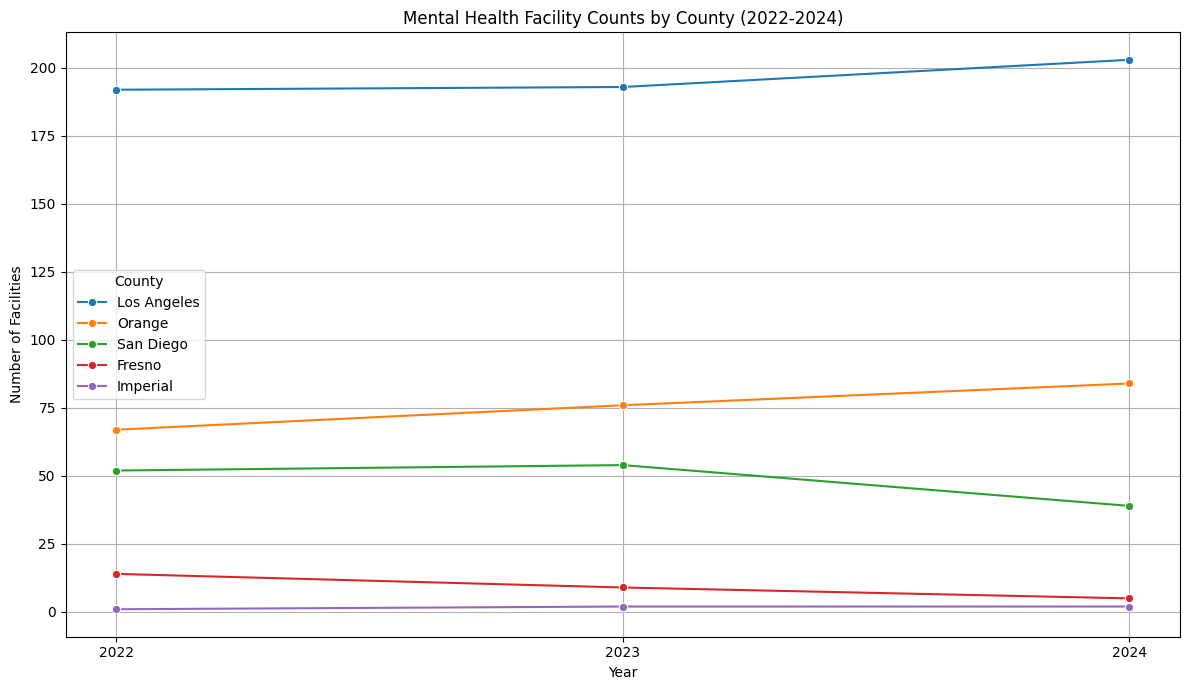

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_2022_counts = final_df_mh_2022['county'].value_counts().reset_index()
df_2022_counts.columns = ['County', 'Facility_Count']
df_2022_counts['Year'] = 2022

df_2023_counts = final_df_mh_2023['county'].value_counts().reset_index()
df_2023_counts.columns = ['County', 'Facility_Count']
df_2023_counts['Year'] = 2023

df_2024_counts = final_df_mh_2024['county'].value_counts().reset_index()
df_2024_counts.columns = ['County', 'Facility_Count']
df_2024_counts['Year'] = 2024

combined_df_mh_counts = pd.concat([
    df_2022_counts,
    df_2023_counts,
    df_2024_counts
]).reset_index(drop=True)

print("Combined Mental Health Facility Counts (2022-2024):")
display(combined_df_mh_counts)

plt.figure(figsize=(12, 7))
sns.lineplot(data=combined_df_mh_counts, x='Year', y='Facility_Count', hue='County', marker='o')

plt.title('Mental Health Facility Counts by County (2022-2024)')
plt.xlabel('Year')
plt.ylabel('Number of Facilities')
plt.xticks(ticks=[2022, 2023, 2024])
plt.grid(True)
plt.legend(title='County')
plt.tight_layout()
plt.show()